# Finetuning LLMs with LoRA & QLoRA

**References**
- [PyTorch blog: Finetune LLMs with HF ecosystem](https://pytorch.org/blog/finetune-llms/).
- [HF LLM Course: LoRA (chapter 11.4)](https://huggingface.co/learn/llm-course/chapter11/4)

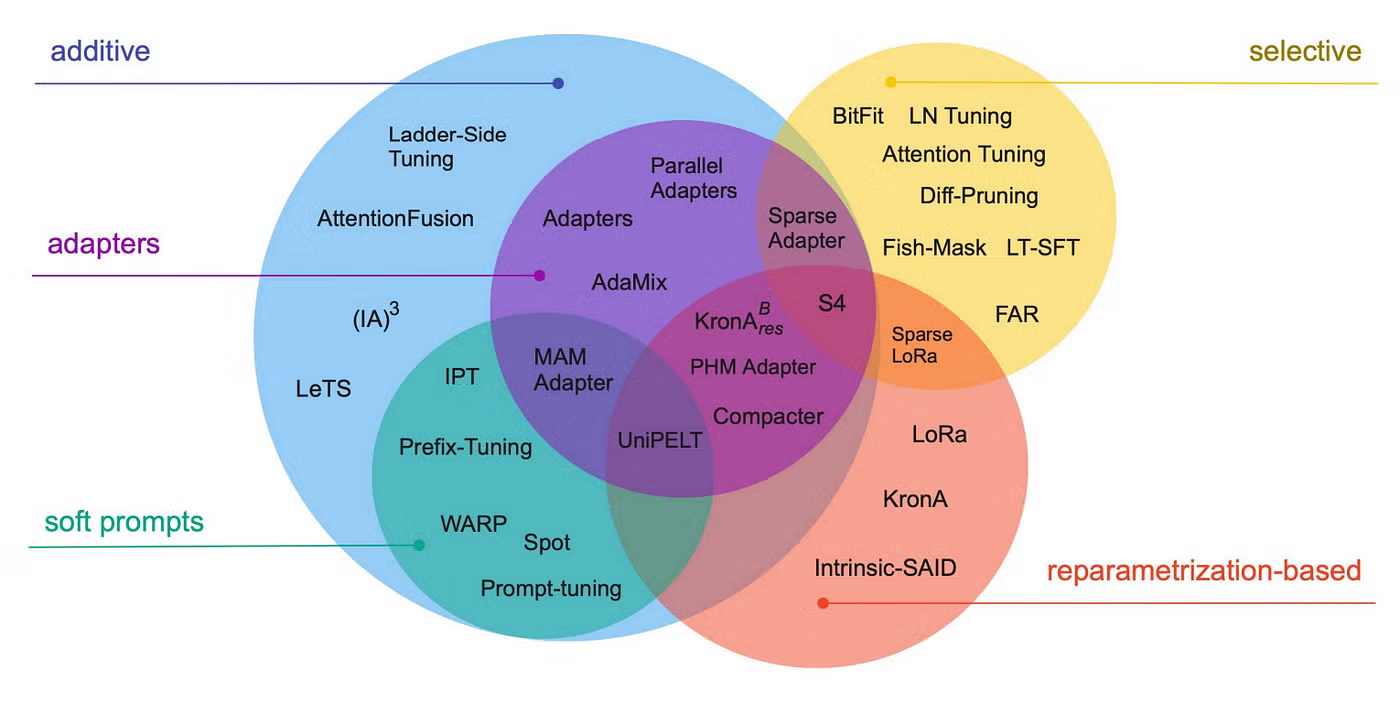

https://arxiv.org/pdf/2303.15647

In [ ]:
!pip -q install --upgrade transformers accelerate datasets bitsandbytes peft trl sentencepiece einops evaluate
import torch, platform, os, transformers, datasets, peft, bitsandbytes, trl
print('Torch:', torch.__version__)
print('CUDA available?', torch.cuda.is_available())
!nvidia-smi || true

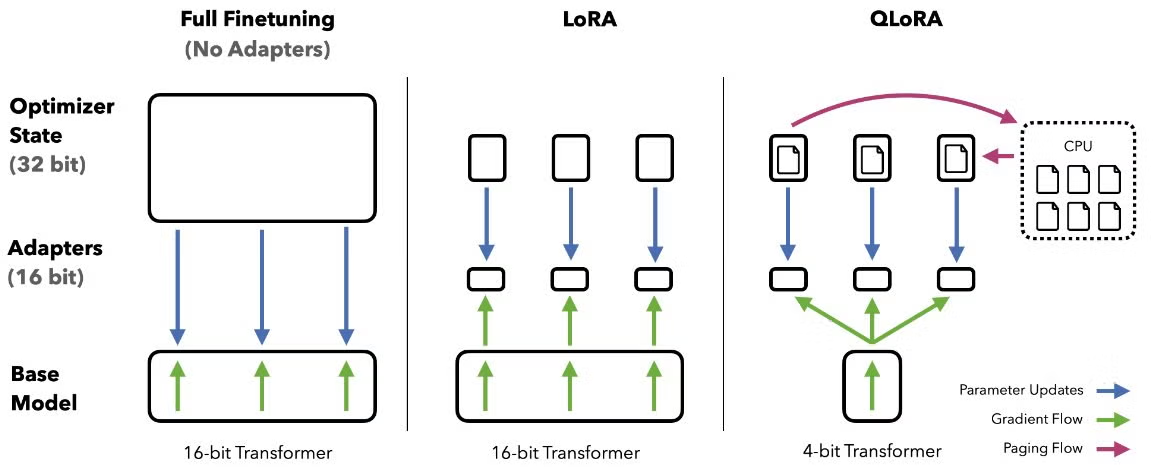

Config

In [ ]:
from dataclasses import dataclass

@dataclass
class Config:
    base_model: str = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    dataset_name: str = "databricks/databricks-dolly-15k"   # clean, instruction-following sets
    subset_size: int = 5000
    # Memory mode:
    # - True  = QLoRA: load base in 4-bit (NF4)
    # - False = LoRA:  full-precision base
    use_qlora: bool = True                                  # True: 4-bit QLoRA; False: FP16 LoRA
    # LoRA hyperparameters:
    lora_r: int = 16                                        # rank of the low-rank adapters (typical 8–64; 16 is a safe default)
    lora_alpha: int = 32                                    # scaling factor (effective scale ~ alpha / r)
    lora_dropout: float = 0.05                              # regularization on adapter activations (0.05–0.1 common)
    max_steps: int = 300
    # Effective batch = batch_size * grad_accum_steps * num_gpus
    per_device_train_batch_size: int = 1                    # micro-batch size
    gradient_accumulation_steps: int = 8                    # number of micro-batches to accumulate before one optimizer step
    learning_rate: float = 2e-4
    warmup_ratio: float = 0.05
    output_dir: str = "outputs"
    eval_prompts: list = None

cfg = Config()
if cfg.eval_prompts is None:
    cfg.eval_prompts = [
        "Write a friendly two-sentence email confirming a meeting for Friday at 10am about the Q3 roadmap.",
        "Explain LoRA to a junior ML engineer in 3 bullet points.",
        "Summarize this dialogue in one sentence: Alice: how's the status? Bob: shipped v1 yesterday, patch coming Monday.",
        "If a recipe calls for 3/4 cup of sugar but you only have 1/2-cup measure, how many scoops do you need?"
    ]

cfg

Load tokenizer & model

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# load tokenizer
tokenizer = AutoTokenizer.from_pretrained(cfg.base_model, use_fast=True)
tokenizer.padding_side = "right"
tokenizer.pad_token = tokenizer.eos_token if tokenizer.pad_token_id is None else tokenizer.pad_token

bnb_config = None
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

# load base model
# QLoRA path: load *frozen* base in 4-bit.
# Non-QLoRA path: regular FP16/BF16 weights.
if cfg.use_qlora:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,                 # quantize base weights to 4-bit
        bnb_4bit_use_double_quant=True,    # second quantization step → smaller memory, similar quality
        bnb_4bit_quant_type="nf4",         # NormalFloat4 (better for weights than int4)
        bnb_4bit_compute_dtype=dtype,      # do math in bf16 (Ampere+) or fp16 (Turing)
    )
    model = AutoModelForCausalLM.from_pretrained(
        cfg.base_model,
        device_map="auto",                 # place layers across available devices (GPU/CPU)
        quantization_config=bnb_config,    # activate 4-bit loading
        trust_remote_code=True,
    )
else:
    model = AutoModelForCausalLM.from_pretrained(
        cfg.base_model,
        torch_dtype=dtype,
        device_map="auto",
        trust_remote_code=True,
    )

print('Loaded model:', cfg.base_model)

check baseline responses

In [ ]:
from textwrap import indent
import torch

def generate(prompt, max_new_tokens=256, temperature=0.7):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, temperature=temperature, do_sample=True)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

pre_eval = {}
for p in cfg.eval_prompts:
    pre_eval[p] = generate(p)

print("=== BASELINE RESPONSES ===")
for p, out in pre_eval.items():
    print("\n# Prompt:\n", p)
    print("\n# Response (baseline):\n", indent(out, '  '))

Load & prepare datase

In [ ]:
from datasets import load_dataset
import random

ds = load_dataset(cfg.dataset_name)

# mapping
def format_example(ex):
    if cfg.dataset_name.startswith("databricks/databricks-dolly-15k"):
        # Dolly fields: instruction, context, response
        instr = ex.get("instruction", "")
        ctx = ex.get("context", "")
        prompt = f"Instruction: {instr}\n"
        if ctx:
            prompt += f"Context: {ctx}\n"
        prompt += "Answer:"
        answer = ex.get("response", "")
        return {"prompt": prompt, "response": answer}
    else:
        # Fallback: try 'text' or 'prompt/response' style
        if "prompt" in ex and "response" in ex:
            return {"prompt": ex["prompt"], "response": ex["response"]}
        return {"prompt": ex.get("instruction", str(ex)), "response": ex.get("output", ex.get("response", ""))}

def prepare_split(dataset, split="train"):
    data = dataset[split]
    if cfg.subset_size and len(data) > cfg.subset_size:
        data = data.shuffle(seed=42).select(range(cfg.subset_size))
    mapped = data.map(format_example, remove_columns=data.column_names)
    return mapped

train_ds = prepare_split(ds, "train")
print(train_ds[0])
print("Train size:", len(train_ds))

In [ ]:
import re

def _clean_prompt_completion(ex):
    # single training newline on prompt, strip leading space on completion
    prompt = re.sub(r"\s+$", "", ex["prompt"]) + "\n"
    completion = ex["completion"].lstrip()
    return {"prompt": prompt, "completion": completion}

if "response" in train_ds.column_names and "completion" not in train_ds.column_names:
    train_ds = train_ds.rename_columns({"response": "completion"})

train_ds = train_ds.map(_clean_prompt_completion)

In [ ]:
# import torch
# from peft import PeftModel
# from transformers import AutoModelForCausalLM, BitsAndBytesConfig

# def reload_base_model():
#     dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
#     if cfg.use_qlora:
#         bnb_config = BitsAndBytesConfig(
#             load_in_4bit=True, bnb_4bit_use_double_quant=True,
#             bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=dtype
#         )
#         return AutoModelForCausalLM.from_pretrained(
#             cfg.base_model, device_map="auto", quantization_config=bnb_config, trust_remote_code=True
#         )
#     else:
#         return AutoModelForCausalLM.from_pretrained(
#             cfg.base_model, torch_dtype=dtype, device_map="auto", trust_remote_code=True
#         )

# try:
#     if isinstance(model, PeftModel):
#         del model
#         torch.cuda.empty_cache()
#         model = reload_base_model()
#         print("Reloaded clean base model for a fresh PEFT attach.")
# except NameError:
#     pass

In [ ]:
import inspect
from trl import SFTTrainer, SFTConfig
from peft import LoraConfig

# modules for adaptation
target_modules = ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]

# LoRA config
peft_config = LoraConfig(
    r=cfg.lora_r, lora_alpha=cfg.lora_alpha, lora_dropout=cfg.lora_dropout,
    bias="none", task_type="CAUSAL_LM", target_modules=target_modules
)

# SFTConfig
sftconf_sig = inspect.signature(SFTConfig.__init__)
sftconf_kwargs = dict(
    output_dir=cfg.output_dir,
    per_device_train_batch_size=cfg.per_device_train_batch_size,
    gradient_accumulation_steps=cfg.gradient_accumulation_steps,
    learning_rate=cfg.learning_rate,
    logging_steps=10,
    max_steps=cfg.max_steps,
    warmup_ratio=cfg.warmup_ratio,
    fp16=not cfg.use_qlora,
    bf16=True if cfg.use_qlora else False,
    optim="paged_adamw_8bit" if cfg.use_qlora else "adamw_torch",
    gradient_checkpointing=True,
    packing=False,
    report_to="none"
)

args = SFTConfig(**sftconf_kwargs)

# Trainer kwargs
trainer_sig = inspect.signature(SFTTrainer.__init__)
trainer_kwargs = dict(model=model, args=args, peft_config=peft_config, train_dataset=train_ds)
if "processing_class" in trainer_sig.parameters:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_sig.parameters:
    trainer_kwargs["tokenizer"] = tokenizer
if "dataset_text_field" in trainer_sig.parameters:
    trainer_kwargs["dataset_text_field"] = None  # explicit

# trainer init
trainer = SFTTrainer(**trainer_kwargs)

# check params
trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
total = sum(p.numel() for p in trainer.model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,} ({100*trainable/total:.3f}%)")

train

In [ ]:
train_result = trainer.train()
train_result

check post-training responses

In [ ]:
trainer.model.eval()
trainer.model.config.use_cache = True
import torch


if cfg.use_qlora:
    autocast_dtype = torch.bfloat16
else:
    autocast_dtype = torch.bfloat16

def generate_eval(prompt: str, max_new_tokens: int = 256, temperature: float = 0.7):
    # tokenize
    inputs = tokenizer(prompt, return_tensors="pt").to(trainer.model.device)
    with torch.no_grad():
        if autocast_dtype in (torch.float16, torch.bfloat16):
            with torch.autocast("cuda", dtype=autocast_dtype):
                out = trainer.model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=True,
                    temperature=temperature,
                    pad_token_id=tokenizer.eos_token_id,
                    eos_token_id=tokenizer.eos_token_id,
                )
        else:
            out = trainer.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=temperature,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
    return tokenizer.decode(out[0], skip_special_tokens=True)

post_eval = {}
for p in cfg.eval_prompts:
    post_eval[p] = generate_eval(p)

print("=== POST-TUNING RESPONSES ===")
from textwrap import indent
for p in cfg.eval_prompts:
    print("\n# Prompt:\n", p)
    print("\n# Before:\n", indent(pre_eval[p], '  '))
    print("\n# After:\n", indent(post_eval[p], '  '))

save model

In [ ]:
import os
adapter_dir = os.path.join(cfg.output_dir, "lora_adapter")
trainer.model.save_pretrained(adapter_dir)
tokenizer.save_pretrained(adapter_dir)
print("Saved LoRA adapter to:", adapter_dir)